In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from PIL import Image
from tqdm import tqdm
import matplotlib.pyplot as plt
import numpy as np
from fvcore.nn import FlopCountAnalysis
import torch
from torchvision import transforms as T, models
import pandas as pd


In [ ]:
df = pd.read_parquet('./UTKFACE_dataset.parquet')
df.head()

,image_path,age,gender,race,race_decoded,gender_decoded
19,./UTKFACE/10_0_0_20161220222308131.jpg,10,0,0,White,Male
20,./UTKFACE/10_0_0_20170103200329407.jpg,10,0,0,White,Male
21,./UTKFACE/10_0_0_20170103200522151.jpg,10,0,0,White,Male
22,./UTKFACE/10_0_0_20170103233459275.jpg,10,0,0,White,Male
23,./UTKFACE/10_0_0_20170104013211746.jpg,10,0,0,White,Male


In [ ]:
# Split estratificado por edad, mantenemos el desbalance todo el momento.
# Train -> 80%
# Validation -> 10%
# Test -> 10%

train_df, temp_df = train_test_split(df, test_size = 0.20, stratify = df['age'], random_state = 42)

val_df, test_df = train_test_split(temp_df, test_size=0.50, stratify = temp_df['age'], random_state = 42)

print(f"""
Train:\t{len(train_df)}
Validation:\t{len(val_df)}
Test:\t{len(test_df)}
""")



Train:	16308
Validation:	2038
Test:	2039



In [9]:
ages = test_df['age'].values
train_ages = train_df['age'].values

In [10]:
# Baseline 1: Random (entre 1 y max_age)
max_age = 80 

random_preds = np.random.randint(1, max_age+1, size=len(ages))
mae_random = np.mean(np.abs(random_preds - ages))

print(f"MAE Random: {mae_random:.3f}")


MAE Random: 25.564


In [11]:
# Baseline 2: Prediciendo la media (de train)

mean_age = np.mean(train_ages)
mean_preds = np.full_like(ages, fill_value=mean_age)
mae_mean = np.mean(np.abs(mean_preds - ages))

print(f"Media = {mean_age:.2f} | MAE Media: {mae_mean:.3f}")


Media = 30.61 | MAE Media: 14.292


In [12]:
# Baseline 3: Prediciendo la mediana (de train)

median_age = np.median(train_ages)
median_preds = np.full_like(ages, fill_value=median_age)
mae_median = np.mean(np.abs(median_preds - ages))

print(f"Mediana = {median_age:.2f} | MAE Mediana: {mae_median:.3f}")


Mediana = 28.00 | MAE Mediana: 14.173


In [ ]:
def get_flops(model, input_torch):
    from fvcore.nn import FlopCountAnalysis
    flops = FlopCountAnalysis(model, input_torch)
    gflops = flops.total() / 1e9
    return round(gflops, 2)

In [ ]:
x = torch.randn(1, 3, 224, 224)

In [40]:
df = [
    {
        'model_name' : 'arcFace',
        'flops' : get_flops(models.resnet101(weights='IMAGENET1K_V1').eval(), x),
        'MAE' : 6.1852
    },
    {
        'model_name' : 'resnet18',
        'flops' : get_flops(models.resnet18(weights='IMAGENET1K_V1').eval(), x),
        'MAE' : 5.9265
    },
    {
        'model_name' : 'resnet50',
        'flops' : get_flops(models.resnet50(weights='IMAGENET1K_V1').eval(), x),
        'MAE' : 5.8672
    },
    {
        'model_name' : 'resnet101',
        'flops' : get_flops(models.resnet101(weights='IMAGENET1K_V1').eval(), x),
        'MAE' : 5.7142
    },
    {
        'model_name' : 'efficientNetS',
        'flops' : get_flops(models.efficientnet_v2_s(weights='IMAGENET1K_V1').eval(), x),
        'MAE' : 5.9078
    },
    {
        'model_name' : 'efficientNetM',
        'flops' : get_flops(models.efficientnet_v2_m(weights='IMAGENET1K_V1').eval(), x),
        'MAE' : 5.9921
    },
    {
        'model_name' : 'efficientNetL',
        'flops' : get_flops(models.efficientnet_v2_l(weights='IMAGENET1K_V1').eval(), x),
        'MAE' : 5.3955
    },
]
df_regression = [
    {
        'model_name' : 'resnet18',
        'flops' : get_flops(models.resnet18(weights='IMAGENET1K_V1').eval(), x),
        'MAE' : 6.0315
    },
    {
        'model_name' : 'efficientNetS',
        'flops' : get_flops(models.efficientnet_v2_s(weights='IMAGENET1K_V1').eval(), x),
        'MAE' : 6.9078
    },
    {
        'model_name' : 'efficientNetM',
        'flops' : get_flops(models.efficientnet_v2_m(weights='IMAGENET1K_V1').eval(), x),
        'MAE' : 5.8701
    },
    {
        'model_name' : 'efficientNetL',
        'flops' : get_flops(models.efficientnet_v2_l(weights='IMAGENET1K_V1').eval(), x),
        'MAE' : 5.1594
    },
]

Unsupported operator aten::max_pool2d encountered 1 time(s)
Unsupported operator aten::add_ encountered 33 time(s)
Unsupported operator aten::max_pool2d encountered 1 time(s)
Unsupported operator aten::add_ encountered 8 time(s)
Unsupported operator aten::max_pool2d encountered 1 time(s)
Unsupported operator aten::add_ encountered 16 time(s)
Unsupported operator aten::max_pool2d encountered 1 time(s)
Unsupported operator aten::add_ encountered 33 time(s)
Unsupported operator aten::silu_ encountered 102 time(s)
Unsupported operator aten::add_ encountered 35 time(s)
Unsupported operator aten::sigmoid encountered 30 time(s)
Unsupported operator aten::mul encountered 30 time(s)
Unsupported operator aten::dropout_ encountered 1 time(s)
The following submodules of the model were never called during the trace of the graph. They may be unused, or they were accessed by direct calls to .forward() or via other python methods. In the latter case they will have zeros for statistics, though their st

In [ ]:
df = pd.DataFrame(df)
df_regression = pd.DataFrame(df_regression)

In [42]:
df.head()

,model_name,flops,MAE
0,arcFace,7.83,6.1852
1,resnet18,1.82,5.9265
2,resnet50,4.11,5.8672
3,resnet101,7.83,5.7142
4,efficientNetS,2.88,5.9078


In [43]:
df_regression.head()

,model_name,flops,MAE
0,resnet18,1.82,6.0315
1,efficientNetS,2.88,6.9078
2,efficientNetM,5.41,5.8701
3,efficientNetL,12.31,5.1594


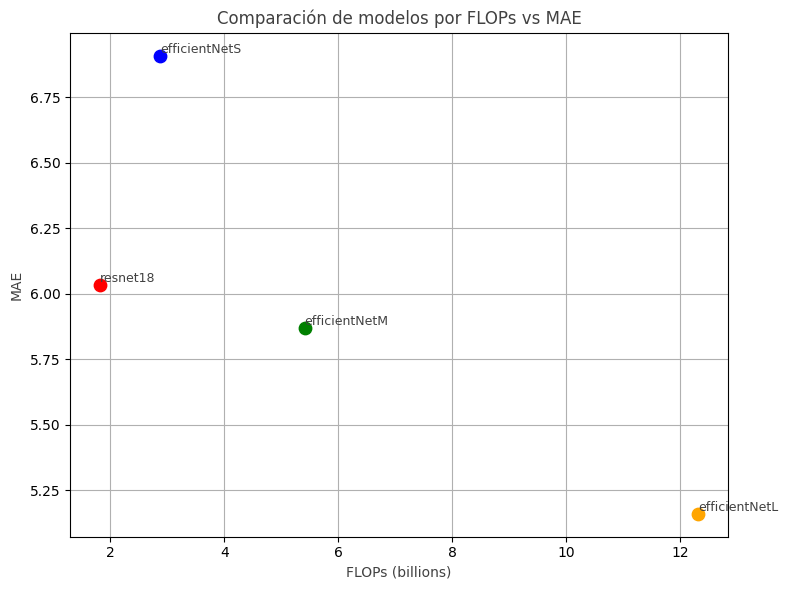

In [ ]:

colors = [
    "red",
    "blue",
    "green",
    "orange",
]

color_map = {model: colors[i % len(colors)] for i, model in enumerate(df_regression['model_name'].unique())}

plt.figure(figsize=(8,6))


for _, row in df_regression.iterrows():
    plt.scatter(row['flops'], row['MAE'], color=color_map[row['model_name']], s=80)
    plt.text(row['flops'], row['MAE'], row['model_name'],
             fontsize=9, ha='left', va='bottom', color = '#414141')

mediana = 14.173
media = 14.292

plt.xlabel("FLOPs (billions)", color = '#414141')
plt.ylabel("MAE", color = '#414141')
plt.title("Comparación de modelos por FLOPs vs MAE", color = '#414141')
plt.grid(True)
plt.tight_layout()
plt.show()


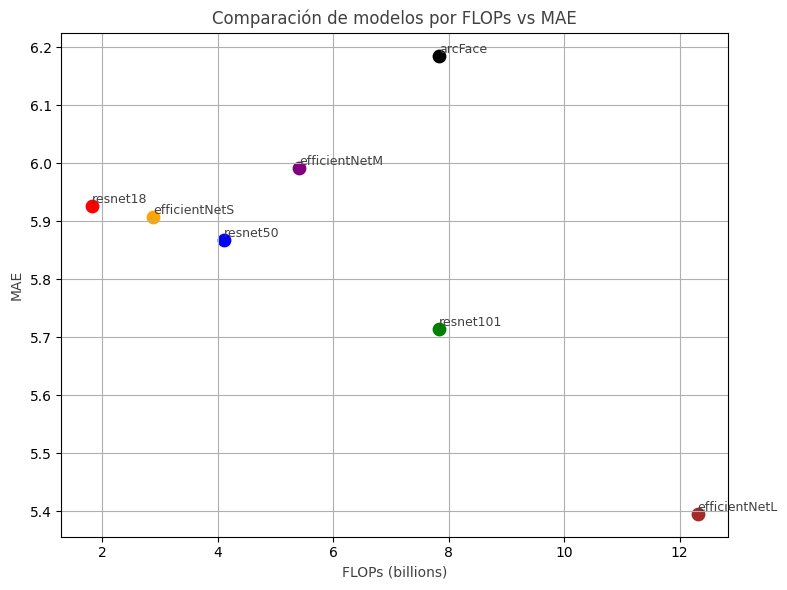

In [ ]:
import matplotlib.pyplot as plt


colors = [
    'black',
    "red",
    "blue",
    "green",
    "orange",
    "purple",
    "brown"
]

color_map = {model: colors[i % len(colors)] for i, model in enumerate(df['model_name'].unique())}

plt.figure(figsize=(8,6))

for _, row in df.iterrows():
    plt.scatter(row['flops'], row['MAE'], color=color_map[row['model_name']], s=80)
    plt.text(row['flops'], row['MAE'], row['model_name'],
             fontsize=9, ha='left', va='bottom', color = '#414141')

mediana = 14.173
media = 14.292

plt.xlabel("FLOPs (billions)", color = '#414141')
plt.ylabel("MAE", color = '#414141')
plt.title("Comparación de modelos por FLOPs vs MAE", color = '#414141')
plt.grid(True)
plt.tight_layout()
plt.show()
